In [1]:
import json
import random
from collections import defaultdict

with open("test_data_cleaned.jsonl", "r", encoding="utf-8") as f:
    all_data = [json.loads(line) for line in f]

lang_data = defaultdict(list)
for item in all_data:
    lang_data[item["lang"]].append(item)

for lang in lang_data:
    random.shuffle(lang_data[lang])

# Define target ratios (English %)
ratios = [0, 10, 20, 30, 40, 50, 60, 70, 80]

for eng_ratio in ratios:
    total_samples = 1000
    eng_count = int((eng_ratio / 100) * total_samples)
    non_eng_count = total_samples - eng_count

    per_non_eng = non_eng_count // 3  # equally from kor, jpn, bul

    new_data = []
    new_data += lang_data["eng_Latn"][:eng_count]
    new_data += lang_data["kor_Hang"][:per_non_eng]
    new_data += lang_data["jpn_Jpan"][:per_non_eng]
    new_data += lang_data["bul_Cyrl"][:per_non_eng]

    random.shuffle(new_data)  # shuffle combined set

    # Save to file
    filename = f"testset_eng_{eng_ratio}.jsonl"
    with open(filename, "w", encoding="utf-8") as f:
        for item in new_data:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")

    print(f"{filename} saved with {len(new_data)} samples (ENG {eng_count}, NON-ENG {non_eng_count})")

testset_eng_0.jsonl saved with 999 samples (ENG 0, NON-ENG 1000)
testset_eng_10.jsonl saved with 1000 samples (ENG 100, NON-ENG 900)
testset_eng_20.jsonl saved with 998 samples (ENG 200, NON-ENG 800)
testset_eng_30.jsonl saved with 999 samples (ENG 300, NON-ENG 700)
testset_eng_40.jsonl saved with 1000 samples (ENG 400, NON-ENG 600)
testset_eng_50.jsonl saved with 998 samples (ENG 500, NON-ENG 500)
testset_eng_60.jsonl saved with 999 samples (ENG 600, NON-ENG 400)
testset_eng_70.jsonl saved with 1000 samples (ENG 700, NON-ENG 300)
testset_eng_80.jsonl saved with 998 samples (ENG 800, NON-ENG 200)


In [2]:
import os
import json
import torch
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_id = "allenai/OLMoE-1B-7B-0924"
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)
model.eval()

# Attach hooks to router layer 14
router_logs = {}
def get_router_hook(layer_name):
    def hook(module, inputs, outputs):
        val = outputs[1] if isinstance(outputs, tuple) else outputs
        if isinstance(val, torch.Tensor) and val.shape[-1] == 64:
            router_logs[layer_name] = val.detach().float().cpu()
    return hook

# Clear old hooks
for name, module in model.named_modules():
    if hasattr(module, "_forward_hooks"):
        module._forward_hooks.clear()

# Register hooks for layer 14
target_layer = "model.layers.14.mlp.gate"
for name, module in model.named_modules():
    if name == target_layer:
        module.register_forward_hook(get_router_hook(name))
        print(f"Hook registered at {name}")

# Loop over all testset files
ratios = [0, 10, 20, 30, 40, 50, 60, 70, 80]
for ratio in ratios:
    file_path = f"testset_eng_{ratio}.jsonl"
    print(f"\nRunning inference on: {file_path}")

    # Load test data
    with open(file_path, "r", encoding="utf-8") as f:
        test_data = [json.loads(line) for line in f]

    # Run inference and capture router logs
    router_data = []
    for i, item in enumerate(tqdm(test_data)):
        lang = item["lang"]
        text = item["text"]
        inputs = tokenizer(text, return_tensors="pt").to(model.device)
        router_logs.clear()
        with torch.no_grad():
            _ = model(**inputs)
        if target_layer in router_logs:
            logits = router_logs[target_layer]
            expert_ids = logits.argmax(dim=-1).tolist()
            token_strs = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
            for idx, expert in enumerate(expert_ids):
                router_data.append({
                    "lang": lang,
                    "sentence_id": i,
                    "token_idx": idx,
                    "token_str": token_strs[idx],
                    "expert_id": expert
                })

    # Save to CSV
    df = pd.DataFrame(router_data)
    out_path = f"router_logs_eng_{ratio}.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Hook registered at model.layers.14.mlp.gate

Running inference on: testset_eng_0.jsonl


100%|█████████████████████████████████████████████████████████████████████████████████| 999/999 [15:32<00:00,  1.07it/s]


Saved: router_logs_eng_0.csv

Running inference on: testset_eng_10.jsonl


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [14:59<00:00,  1.11it/s]


...

Saved: router_logs_eng_60.csv

Running inference on: testset_eng_70.jsonl


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [14:21<00:00,  1.16it/s]


Saved: router_logs_eng_70.csv

Running inference on: testset_eng_80.jsonl


100%|█████████████████████████████████████████████████████████████████████████████████| 998/998 [14:12<00:00,  1.17it/s]

Saved: router_logs_eng_80.csv


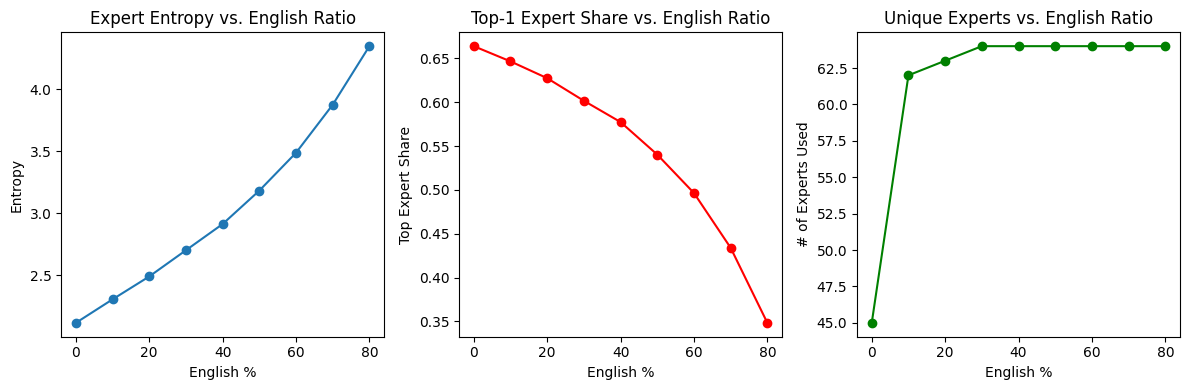

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ratios = [0, 10, 20, 30, 40, 50, 60, 70, 80]
entropies = []
top1_shares = []
unique_expert_counts = []

def compute_entropy(counts):
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

for ratio in ratios:
    df = pd.read_csv(f"router_logs_eng_{ratio}.csv")
    
    expert_counts = df['expert_id'].value_counts().sort_values(ascending=False)
    
    # Entropy
    entropy = compute_entropy(expert_counts.values)
    entropies.append(entropy)
    
    # Top-1 expert
    top1_share = expert_counts.iloc[0] / expert_counts.sum()
    top1_shares.append(top1_share)
    
    # Unique expert
    unique_expert_counts.append(len(expert_counts))

# Plotting
plt.figure(figsize=(12, 4))

# 1. Entropy
plt.subplot(1, 3, 1)
plt.plot(ratios, entropies, marker='o')
plt.title("Expert Entropy vs. English Ratio")
plt.xlabel("English %")
plt.ylabel("Entropy")

# 2. Top-1
plt.subplot(1, 3, 2)
plt.plot(ratios, top1_shares, marker='o', color='red')
plt.title("Top-1 Expert Share vs. English Ratio")
plt.xlabel("English %")
plt.ylabel("Top Expert Share")

# 3. Unique Experts
plt.subplot(1, 3, 3)
plt.plot(ratios, unique_expert_counts, marker='o', color='green')
plt.title("Unique Experts vs. English Ratio")
plt.xlabel("English %")
plt.ylabel("# of Experts Used")

plt.tight_layout()
plt.show()